<a href="https://colab.research.google.com/github/SahilKumar-003/Customer-Churn-Analysis-Python/blob/main/Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [71]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [73]:
df['TotalCharges'] = df['TotalCharges'].replace(" ",0)
df['TotalCharges'] = df['TotalCharges'].astype("float")


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [75]:
df.isnull().sum().sum()

np.int64(0)

In [76]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df['customerID'].duplicated().sum()

np.int64(0)

In [79]:
df['SeniorCitizen'].unique()


array([0, 1])

***Converted 0 and 1 of senior citizens into yes and no***


In [83]:
# df['SeniorCitizen'] = df['SeniorCitizen'].map({0: "No", 1: "Yes"})
def conv(value):
  if value == 1:
    return "Yes"
  else:
    return "No"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

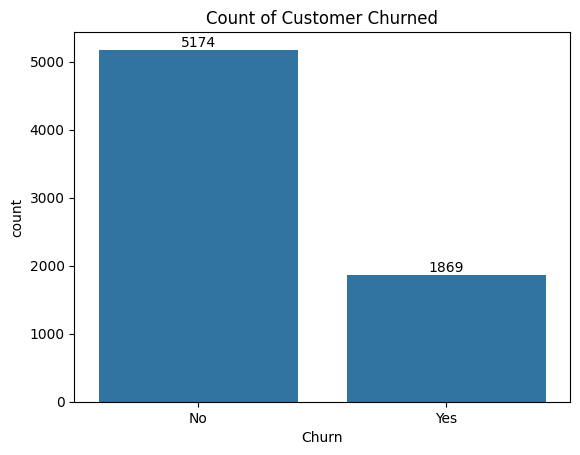

In [96]:
ax = sns.countplot(x = 'Churn', data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customer Churned",fontsize = 12)
plt.show()

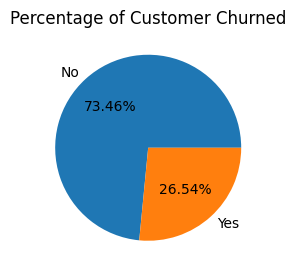

In [97]:
plt.figure(figsize= (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'],labels = gb.index, autopct= "%1.2f%%")
plt.title("Percentage of Customer Churned")
plt.show()

***From the given pie chart we can figure out that 26.54% of our customer churned out . let's explore the reason behind it***

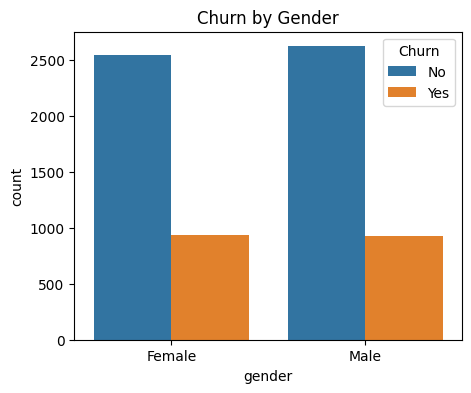

In [108]:
plt.figure(figsize = (5,4))
sns.countplot(x = 'gender', data =df, hue = 'Churn')
plt.title("Churn by Gender")
plt.show()

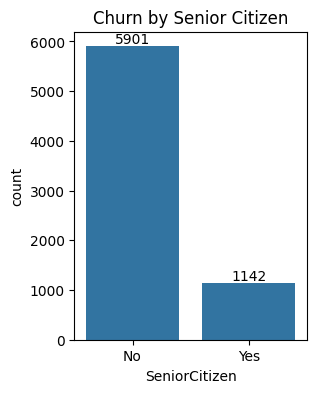

In [114]:
plt.figure(figsize = (3,4))
ax = sns.countplot(x = 'SeniorCitizen', data =df)
ax.bar_label(ax.containers[0])
plt.title("Churn by Senior Citizen")
plt.show()

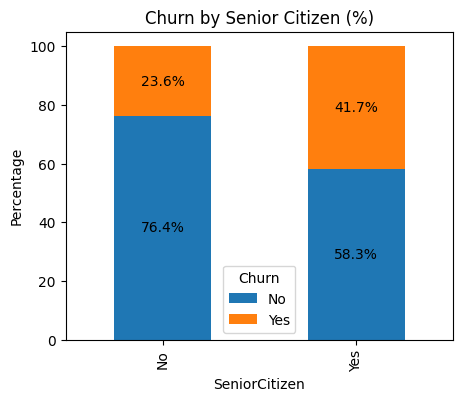

In [112]:
# Create percentage table
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

# Plot stacked bar
ax = ct.plot(kind='bar', stacked=True, figsize=(5,4))

plt.title("Churn by Senior Citizen (%)")
plt.ylabel("Percentage")
plt.xlabel("SeniorCitizen")
plt.legend(title="Churn")

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.show()


***Comparatively a greater percentage of people in senior citizen have churned***

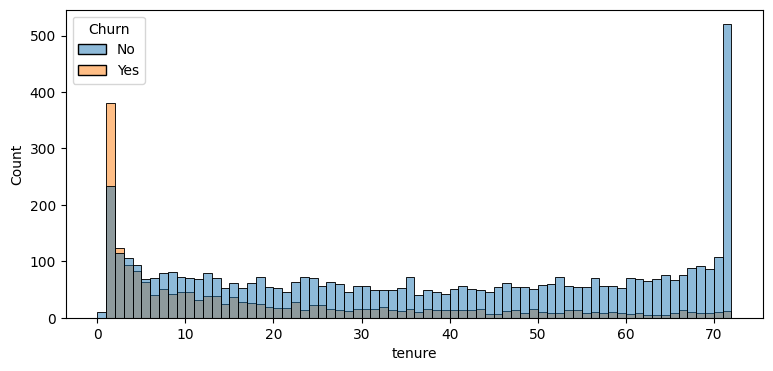

In [120]:
plt.figure(figsize = (9,4))
sns.histplot(x = 'tenure' , data = df, bins = 72, hue = 'Churn')
plt.show()

***People who have used are services for a long time have stayed and people who have used our services for 1 or 2 months have churned***

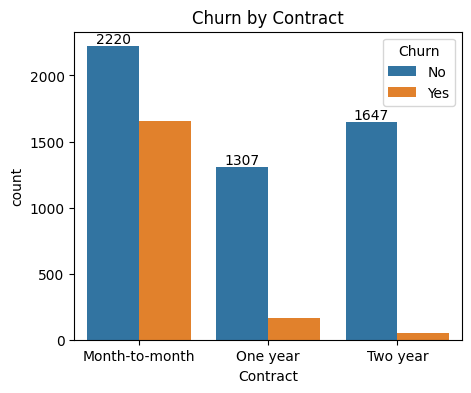

In [123]:
plt.figure(figsize = (5,4))
ax = sns.countplot(x = 'Contract', data =df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title("Churn by Contract")
plt.show()

***People who have month to month contract are likely to churn then from those who have 1  to 2 year of contract***

In [124]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

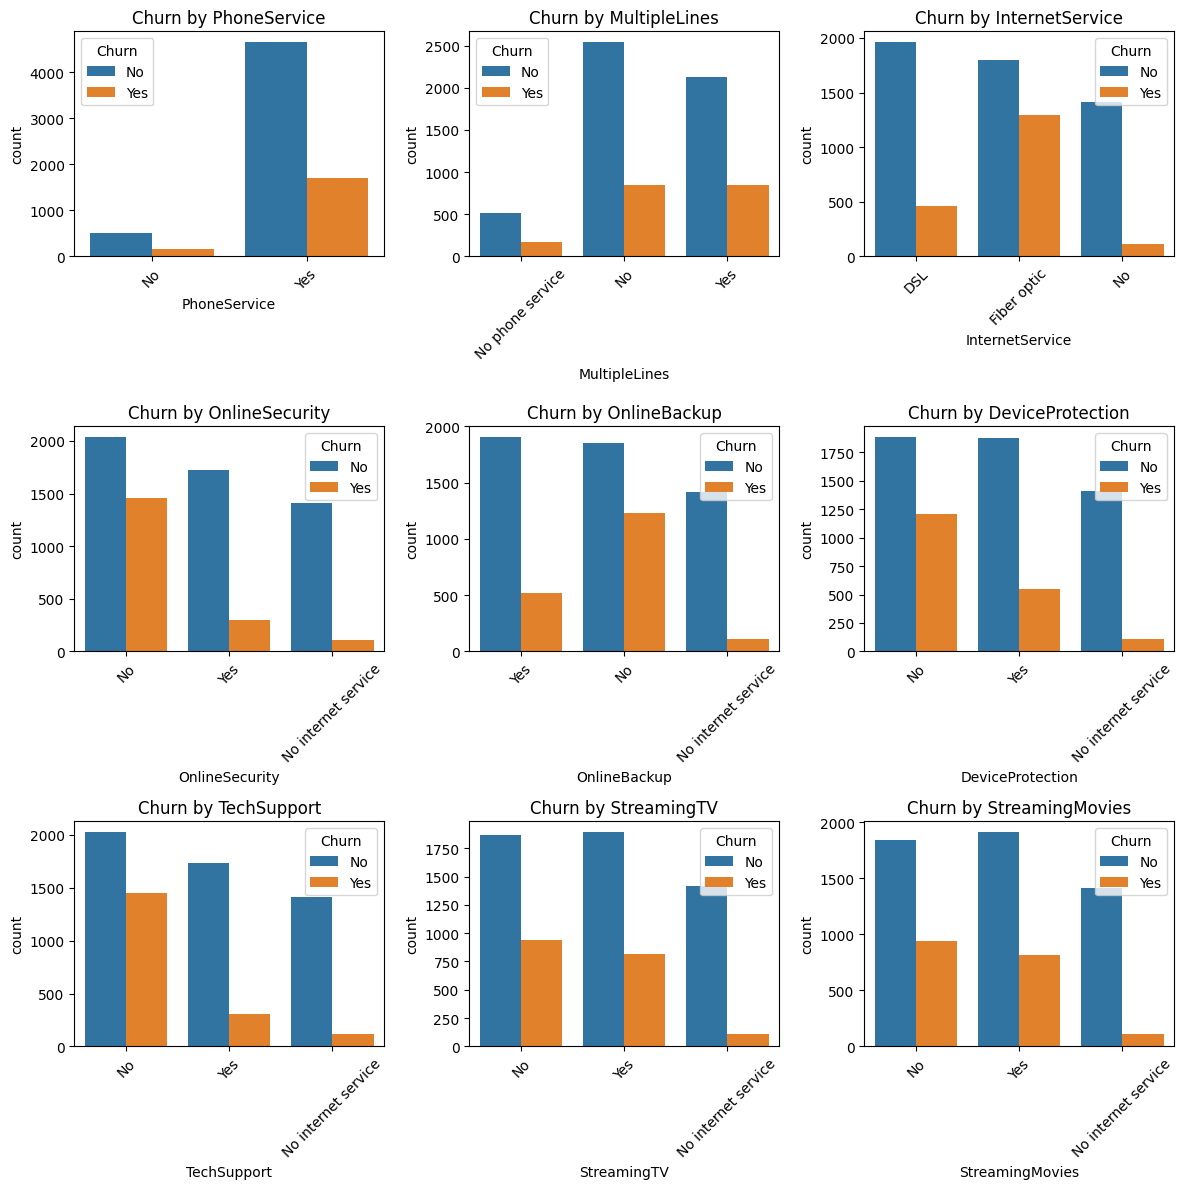

In [128]:
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

plt.figure(figsize=(12, 12))

for i, col in enumerate(cols):
    plt.subplot(3, 3, i+1)   # 3 rows, 3 columns
    sns.countplot(x=col, data=df, hue='Churn')
    plt.title(f"Churn by {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

***The churn analysis shows that customers using Fiber optic Internet have the highest churn rate. Customers without OnlineSecurity and TechSupport also churn significantly more. OnlineBackup and DeviceProtection reduce churn. Features like PhoneService, MultipleLines, StreamingTV, and StreamingMovies have minimal impact on churn.***

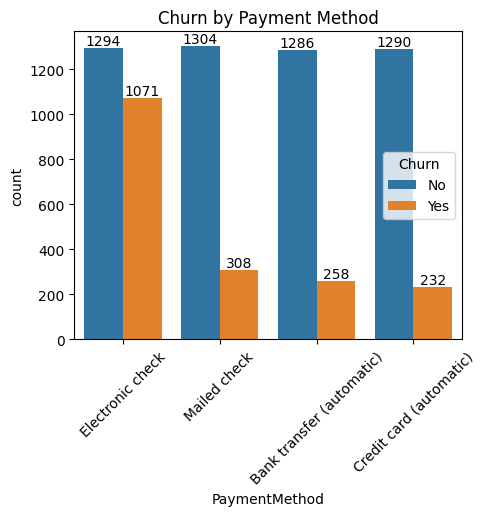

In [132]:
plt.figure(figsize = (5,4))
ax = sns.countplot(x = 'PaymentMethod', data =df, hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Payment Method")
plt.xticks(rotation = 45)
plt.show()

***Customer is likely to churn when he is using Electronic check***